In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv('dd_pivot.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)

In [69]:
df

,INIT_STATE,CENTER_Q,circ,dd_uhrig,dd_uniform,rel_change_dd_uniform,rel_change_dd_uhrig,rel_avg,rel_err
0,0,15,0.2156,0.2958,0.2991,0.387291,0.371985,0.379638,0.007653
1,0,34,0.3095,0.4583,0.4699,0.518255,0.480775,0.499515,0.018740
2,0,54,0.4117,0.3834,0.3880,-0.057566,-0.068739,-0.063153,0.005587
3,0,72,0.1306,0.3709,0.3833,1.934916,1.839969,1.887443,0.047473
4,0,93,0.1198,0.4939,0.4958,3.138564,3.122705,3.130634,0.007930
5,0,109,0.1104,0.4775,0.4726,3.280797,3.325181,3.302989,0.022192
6,1,15,0.7656,0.3107,0.3318,-0.566614,-0.594175,-0.580394,0.013780
7,1,34,0.7387,0.3049,0.3230,-0.562745,-0.587248,-0.574997,0.012251
8,1,54,0.5132,0.3536,0.3401,-0.337295,-0.310990,-0.324143,0.013153
9,1,72,0.5991,0.2907,0.3033,-0.493741,-0.514772,-0.504256,0.010516


In [83]:
# Melt for seaborn
df_melted = df.melt(
    id_vars=["CENTER_Q", "INIT_STATE"],
    value_vars=["circ", "dd_uniform", "dd_uhrig"],
    var_name="DD Method",
    value_name="flip_rate"
)

In [85]:
# Rename method values
df_melted["DD Method"] = df_melted["DD Method"].replace({
    "circ": "None",
    "dd_uniform": "Uniform",
    "dd_uhrig": "Uhrig"
})

In [87]:
df_melted

,CENTER_Q,INIT_STATE,DD Method,flip_rate
0,15,0,None,0.2156
1,34,0,None,0.3095
2,54,0,None,0.4117
3,72,0,None,0.1306
4,93,0,None,0.1198
5,109,0,None,0.1104
6,15,1,None,0.7656
7,34,1,None,0.7387
8,54,1,None,0.5132
9,72,1,None,0.5991


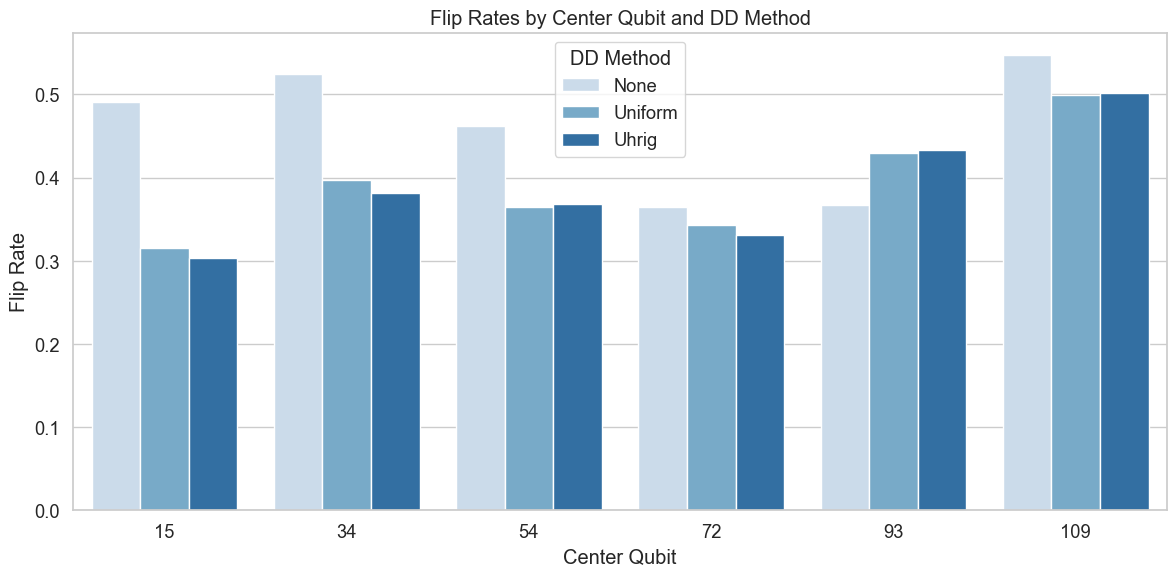

In [97]:
# Set seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted,
    x="CENTER_Q", y="flip_rate",
    hue="DD Method",
    palette="Blues",
    errorbar=None,
    dodge=True
)

plt.title("Flip Rates by Center Qubit and DD Method")
plt.xlabel("Center Qubit")
plt.ylabel("Flip Rate")
plt.legend(title="DD Method")
plt.tight_layout()
plt.savefig('plots/dd_analysis.png')
plt.show()